In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import numpy as np

In [6]:
def plot_quantification_from_csv(df, train_prevalence, title="Real vs Predito (Por Método/Classificador)"):
    """
    Plota a prevalência Real vs Predita a partir de um DataFrame de resultados.
    Agrupa por 'method' e 'classifier' e calcula a média das predições para cada ponto real.

    Args:
        df (pd.DataFrame): DataFrame contendo as colunas 'method', 'classifier', 'pred_pos', 'true_pos'.
        train_prevalence (float): A prevalência da classe positiva no treino.
        title (str): Título do gráfico.
    """
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 1. Linha Ideal (Diagonal)
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='Ideal', alpha=0.6)

    # Cria uma coluna combinada para legenda (ex: "CC - SVM")
    df['model_label'] = df['method'] + ' - ' + df['classifier']
    
    # Identificar modelos únicos
    unique_models = df['model_label'].unique()
    
    # Configuradores de estilo
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_models)))
    markers = itertools.cycle(['o', 's', '^', 'D', 'v', 'X'])
    line_styles = itertools.cycle(['-', '--', '-.'])

    # 2. Iterar sobre cada modelo único
    for model_name, color in zip(unique_models, colors):
        # Filtrar apenas dados deste modelo
        subset = df[df['model_label'] == model_name]
        
        # --- PASSO CRÍTICO: AGREGAÇÃO ---
        # Como podem existir várias bags com o mesmo 'true_pos', agrupamos e tiramos a média
        # para ter uma linha única e limpa.
        grouped = subset.groupby('true_pos')['pred_pos'].mean().reset_index()
        
        # Ordenar por true_pos (eixo X) para garantir que a linha siga a ordem
        grouped = grouped.sort_values('true_pos')
        
        current_marker = next(markers)
        current_ls = next(line_styles)

        ax.plot(grouped['true_pos'], grouped['pred_pos'], 
                label=model_name,
                color=color,
                linestyle=current_ls,
                marker=current_marker,
                markersize=5,
                linewidth=2,
                alpha=0.8)

    # 3. Ponto de Prevalência de Treino
    ax.scatter([train_prevalence], [train_prevalence], 
               color='red', 
               s=250, 
               marker='*', 
               edgecolor='black', 
               zorder=10, 
               label=f'Prevalência Treino ({train_prevalence:.2f})')
    
    # Linhas de referência no ponto de treino
    ax.axvline(x=train_prevalence, color='red', linestyle=':', alpha=0.3)
    ax.axhline(y=train_prevalence, color='red', linestyle=':', alpha=0.3)

    # Configurações do Gráfico
    ax.set_xlabel('Prevalência Real ($p$)', fontsize=12)
    ax.set_ylabel('Prevalência Predita Média ($\hat{p}$)', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle='-', alpha=0.5)
    
    # Posicionar legenda fora se houver muitos modelos, ou dentro se couber
    ax.legend(loc='upper left', frameon=True, fontsize=10)
    
    plt.tight_layout()
    plt.show()

<>:68: SyntaxWarning: invalid escape sequence '\h'
<>:68: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1358897/3572798261.py:68: SyntaxWarning: invalid escape sequence '\h'
  ax.set_ylabel('Prevalência Predita Média ($\hat{p}$)', fontsize=12)


In [7]:
results_ = pd.read_csv('../results/baselines_.csv', index_col=False).drop(['Unnamed: 0'], axis=1)

/tmp/ipykernel_1358897/3572798261.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['model_label'] = df['method'] + ' - ' + df['classifier']


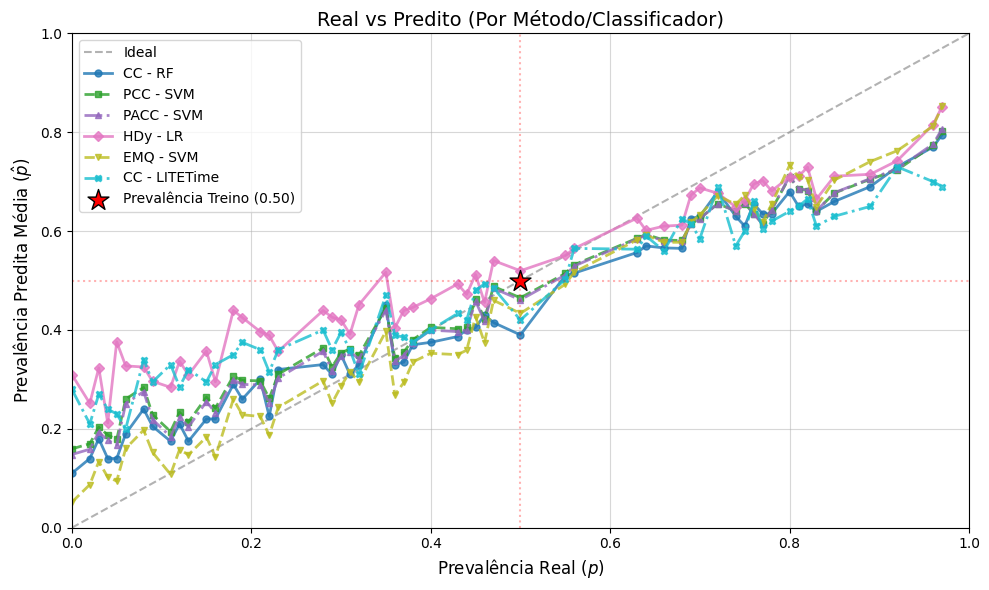

In [11]:
plot_quantification_from_csv(results_[results_['bag_size'] == 100], train_prevalence=0.5)

In [12]:
def plot_quantification_scatter(df, train_prevalence, title="Dispersão: Real vs Predito (Por Bag)"):
    """
    Plota cada bag individualmente como um ponto.
    
    Args:
        df (pd.DataFrame): DataFrame com colunas 'method', 'classifier', 'pred_pos', 'true_pos'.
        train_prevalence (float): A prevalência do treino.
        title (str): Título do gráfico.
    """
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 1. Linha Ideal (Diagonal) - Referência visual
    ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1, label='Ideal', zorder=1)

    # Criar label composta para identificar método + classificador
    df['model_label'] = df['method'] + ' - ' + df['classifier']
    unique_models = df['model_label'].unique()
    
    # Gerar cores distintas para cada modelo
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_models)))
    
    # 2. Iterar sobre cada modelo para plotar seus bags
    for model_name, color in zip(unique_models, colors):
        subset = df[df['model_label'] == model_name]
        
        ax.scatter(subset['true_pos'], subset['pred_pos'], 
                   label=model_name,
                   color=color,
                   alpha=0.5,  # Transparência é CRUCIAL aqui para ver sobreposição
                   s=30,       # Tamanho do ponto
                   edgecolor='white', # Borda branca ajuda a separar pontos densos
                   linewidth=0.5,
                   zorder=2)

    # 3. Ponto de Prevalência de Treino (em destaque)
    ax.scatter([train_prevalence], [train_prevalence], 
               color='yellow', 
               s=300, 
               marker='*', 
               edgecolor='black', 
               linewidth=1.5,
               zorder=10, 
               label=f'Prevalência Treino ({train_prevalence:.2f})')
    
    # Linhas guia no ponto de treino
    ax.axvline(x=train_prevalence, color='red', linestyle=':', alpha=0.4)
    ax.axhline(y=train_prevalence, color='red', linestyle=':', alpha=0.4)

    # Configurações finais
    ax.set_xlabel('Prevalência Real ($p$)', fontsize=12)
    ax.set_ylabel('Prevalência Predita ($\hat{p}$)', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.set_xlim(-0.02, 1.02) # Leve margem para não cortar pontos nos extremos
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, linestyle='-', alpha=0.3)
    
    # Legenda
    ax.legend(loc='upper left', frameon=True)
    
    plt.tight_layout()
    plt.show()

<>:52: SyntaxWarning: invalid escape sequence '\h'
<>:52: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1358897/3836158732.py:52: SyntaxWarning: invalid escape sequence '\h'
  ax.set_ylabel('Prevalência Predita ($\hat{p}$)', fontsize=12)


/tmp/ipykernel_1358897/3836158732.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['model_label'] = df['method'] + ' - ' + df['classifier']


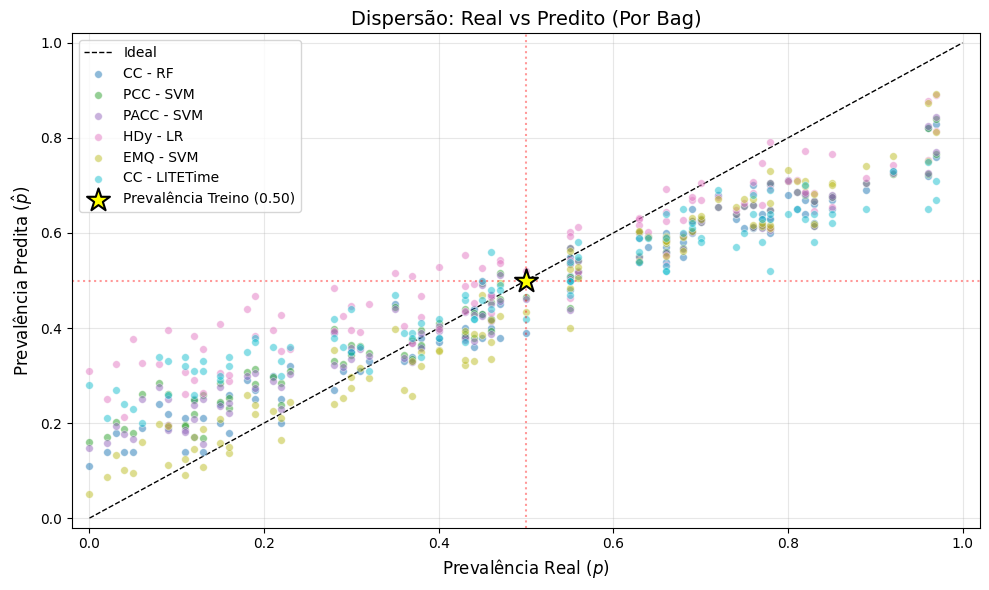

In [14]:
plot_quantification_scatter(results_[results_['bag_size'] == 100], train_prevalence=0.5)

In [ ]:
def plot_quantification_mean_std(df, train_prevalence, bins_decimals=2, title="Quantification error as a function of Prior Probability Shift"):
    """
    Plots the mean and std dev line. Group each bag with approx prevalences using round.

    Args:
        df (pd.DataFrame): DataFrame with 'method', 'classifier', 'pred_pos', 'true_pos' columns.
        train_prevalence (float): Training prevalence.
        bins_decimals (int): Decimal cases to group the bags based on 'true_pos'. 
            Ex: 2 group 0.101 and 0.099 in 0.10.
    """
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Ideal line
    ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1, label='Ideal', alpha=0.6)

    # Method identifier
    df['model_label'] = df['method'] + ' - ' + df['classifier']
    
    df['true_pos_bin'] = df['true_pos'].round(bins_decimals)
    
    unique_models = df['model_label'].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_models)))
    line_styles = itertools.cycle(['-', '-.'])

    for model_name, color in zip(unique_models, colors):
        subset = df[df['model_label'] == model_name]
        
        # Agrupamento: Calculamos Média e Desvio Padrão por bin
        grouped = subset.groupby('true_pos_bin')['pred_pos'].agg(['mean', 'std']).reset_index()
        grouped = grouped.sort_values('true_pos_bin')
        
        # Tratar casos onde só há 1 bag (std vira NaN -> substitui por 0)
        grouped['std'] = grouped['std'].fillna(0)

        ls = next(line_styles)

        # 2. Plotar a Média (Linha)
        ax.plot(grouped['true_pos_bin'], grouped['mean'], 
                label=model_name, 
                color=color, 
                linestyle=ls, 
                linewidth=2)
        
        # 3. Plotar o Desvio Padrão (Sombra/Faixa)
        # alpha baixo (0.2) é essencial para ver sobreposição de modelos
        ax.fill_between(grouped['true_pos_bin'], 
                        grouped['mean'] - grouped['std'], 
                        grouped['mean'] + grouped['std'], 
                        color=color, 
                        alpha=0.2, 
                        edgecolor=None) # Sem borda na sombra para ficar mais limpo

    # 4. Ponto de Treino
    ax.scatter([train_prevalence], [train_prevalence], 
               color='red', 
               s=50, 
               marker='o', 
               edgecolor='black', 
               zorder=10, 
               label=f'Treino ({train_prevalence:.2f})')
    
    # Linhas guia
    ax.axvline(x=train_prevalence, color='red', linestyle=':', alpha=0.3)
    ax.axhline(y=train_prevalence, color='red', linestyle=':', alpha=0.3)

    # Cosmética
    ax.set_xlabel('Prevalência Real ($p$)', fontsize=12)
    ax.set_ylabel('Prevalência Predita ($\hat{p}$)', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle='-', alpha=0.4)
    ax.legend(loc='upper left', frameon=True)
    
    plt.tight_layout()
    plt.show()

<>:69: SyntaxWarning: invalid escape sequence '\h'
<>:69: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1358897/711404378.py:69: SyntaxWarning: invalid escape sequence '\h'
  ax.set_ylabel('Prevalência Predita ($\hat{p}$)', fontsize=12)


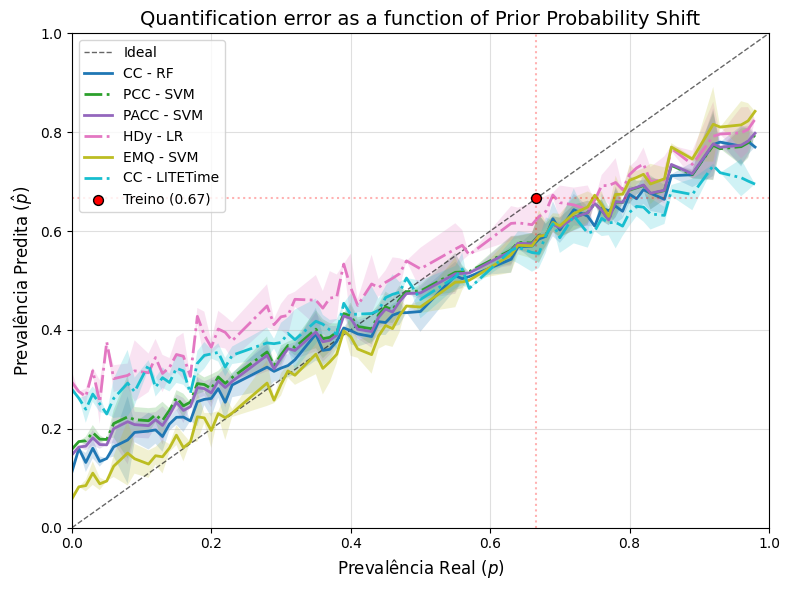

In [32]:
plot_quantification_mean_std(results_, train_prevalence=0.6662583113620425)